In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import seaborn as sn
import numpy as np
import joblib
import pickle
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
import warnings

warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
data = 'D:/Ishita/IGDTUW (CSE)/Summer Internship 2024/Analytics (NER) Healthcare/Datasets/i2b2_2018_annotated.csv'
df = pd.read_csv(data, header=None)

In [4]:
df.columns = df.iloc[0]
df = df[1:]
df.head()

,Word,Label,FileNumber
1,Admission,O,1
2,Date:,O,1
3,[**2115-2-22**],O,1
4,Discharge,O,1
5,Date:,O,1


In [5]:
import re
import spacy

import nltk
import string
#nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
STOP_WORDS = stopwords.words('english')
def clean_word(word):
    
    # remove non-alphanumeric characters and extra whitespaces
    word = re.sub(r'[^\w\s]','',word)
    word = re.sub(r'\s+',' ',word)
    
    # convert to lowercase
    word = word.lower()
    
    if word not in STOP_WORDS:
        return word
    
    return ''

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
words = list(set(df["Word"].values))
words.append("ENDPAD")
num_words = len(words)
words_set = set(words)

# Clean and convert each word in df['Word']
df['Word'] = df['Word'].astype(str).apply(clean_word)

# Filter df to keep rows where 'Word' is in words_set
df = df[df['Word'].isin(words_set)]
words = list(set(df["Word"].values))
words.append("ENDPAD")
num_words = len(words)


tags = list(set(df["Label"].values))
num_tags = len(tags)
word2idx = {w: i + 1 for i, w in enumerate(words)}
tag2idx = {t: i for i, t in enumerate(tags)}

In [7]:
print("Unique words in corpus:", df['Word'].nunique())
print("Unique tags in corpus:", df['Label'].nunique())

Unique words in corpus: 14013
Unique tags in corpus: 19


In [8]:
print(df['Label'].value_counts())

O              465570
B-Drug          23058
B-Form          11323
B-Strength       9257
B-Route          8828
B-Reason         8533
B-Frequency      7758
I-Strength       7158
I-Frequency      6022
I-Dosage         5023
B-Dosage         4825
I-Reason         3740
I-Form           2992
I-Drug           2705
B-ADE            1866
I-Duration       1323
I-ADE             883
I-Route           550
B-Duration        464
Name: Label, dtype: int64


In [9]:
import tqdm
def sentence_integrate(data):
  agg_func = lambda s: [(w, t) for w, t in zip(s["Word"].values.tolist(),
                                                           s["Label"].values.tolist())]
  return df.groupby('FileNumber').apply(agg_func).tolist()
  
sentences=sentence_integrate(data)
  
sentences[0]


[('cough', 'O'),
 ('complaints', 'O'),
 ('time', 'O'),
 ('continued', 'O'),
 ('lose', 'O'),
 ('weight', 'O'),
 ('found', 'O'),
 ('potential', 'O'),
 ('rightsided', 'O'),
 ('dental', 'O'),
 ('abscess', 'O'),
 ('treated', 'O'),
 ('empirically', 'O'),
 ('antibiotics', 'B-Drug'),
 ('continued', 'O'),
 ('weight', 'O'),
 ('loss', 'O'),
 ('diarrhea', 'O'),
 ('seems', 'O'),
 ('end', 'O'),
 ('month', 'O'),
 ('beginning', 'O'),
 ('patient', 'O'),
 ('represented', 'O'),
 ('medical', 'O'),
 ('attention', 'O'),
 ('mild', 'O'),
 ('shortness', 'O'),
 ('breath', 'O'),
 ('exertion', 'O'),
 ('chest', 'O'),
 ('discomfort', 'O'),
 ('also', 'O'),
 ('noted', 'O'),
 ('point', 'O'),
 ('subjective', 'O'),
 ('temperatures', 'O'),
 ('cough', 'O'),
 ('productive', 'O'),
 ('brown', 'O'),
 ('sputum', 'O'),
 ('already', 'O'),
 ('weight', 'O'),
 ('loss', 'O'),
 ('initial', 'O'),
 ('presentation', 'O'),
 ('also', 'O'),
 ('complained', 'O'),
 ('one', 'O'),
 ('episode', 'O'),
 ('hemoptysis', 'O'),
 ('production', 'O'),


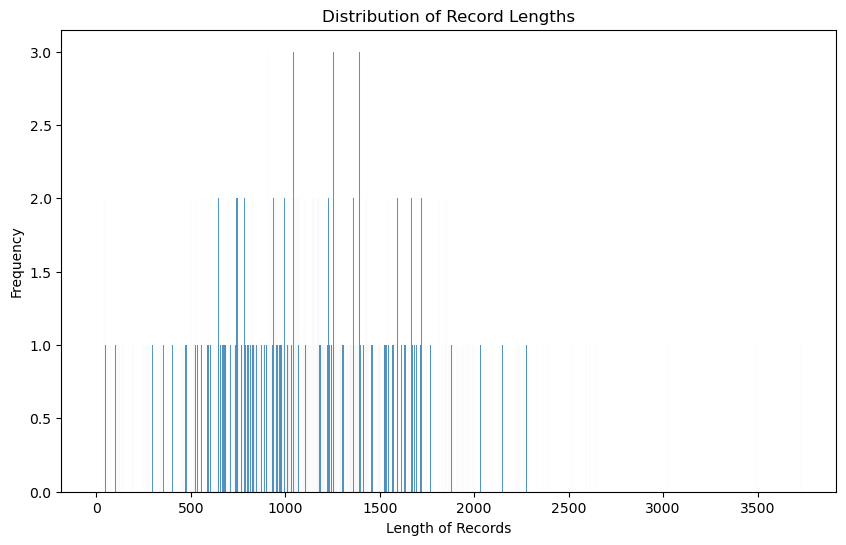

In [10]:
sentence_lengths = [len(sentence) for sentence in sentences]

# Plot the distribution
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(sentence_lengths, bins=range(1, max(sentence_lengths) + 2), kde=False)
plt.title('Distribution of Record Lengths')
plt.xlabel('Length of Records')
plt.ylabel('Frequency')
plt.show()

In [11]:
print(sum(length > 2000 for length in sentence_lengths))

31


In [12]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 2000

X = [[word2idx[w[0]] for w in s] for s in sentences]
X = pad_sequences(maxlen=max_len, sequences=X, padding="post", value=num_words-1)

y = [[tag2idx[w[1]] for w in s] for s in sentences]
y = pad_sequences(maxlen=max_len, sequences=y, padding="post", value=tag2idx["O"])

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size = 0.5, random_state = 42)

In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.optimizers.legacy import Adam

In [15]:
# Define the model architecture
INPUT_DIM = 14014
EMBEDDING_DIM = 64
MAX_LENGTH = 2000
NUM_CLASSES = 20
LSTM1_UNITS = 64
LSTM2_UNITS = 32
DENSE_DIM = 64
DROPOUT = 0.2
BATCH_SIZE = 32
EPOCHS = 30
model = tf.keras.models.Sequential([
    Embedding(INPUT_DIM, EMBEDDING_DIM, input_length=MAX_LENGTH),
    Bidirectional(LSTM(units=LSTM1_UNITS, return_sequences=True)),
    Bidirectional(LSTM(units=LSTM2_UNITS, return_sequences=True)),
    Dense(DENSE_DIM, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])


model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 2000, 64)          896896    
                                                                 
 bidirectional (Bidirectiona  (None, 2000, 128)        66048     
 l)                                                              
                                                                 
 bidirectional_1 (Bidirectio  (None, 2000, 64)         41216     
 nal)                                                            
                                                                 
 dense (Dense)               (None, 2000, 64)          4160      
                                                                 
 dense_1 (Dense)             (None, 2000, 20)          1300      
                                                                 
Total params: 1,009,620
Trainable params: 1,009,620
Non-

In [16]:
# Train the model
history = model.fit(
    X_train, 
    y_train, 
    epochs=EPOCHS, 
    validation_data=(X_val, y_val)
)

Epoch 1/30
13/13 [==============================] - 40s 3s/step - loss: 2.3766 - accuracy: 0.8223 - val_loss: 0.7918 - val_accuracy: 0.9030
Epoch 2/30
13/13 [==============================] - 42s 3s/step - loss: 0.7331 - accuracy: 0.8944 - val_loss: 0.6338 - val_accuracy: 0.9030
Epoch 3/30
13/13 [==============================] - 42s 3s/step - loss: 0.6545 - accuracy: 0.8944 - val_loss: 0.5885 - val_accuracy: 0.9030
Epoch 4/30
13/13 [==============================] - 39s 3s/step - loss: 0.6199 - accuracy: 0.8944 - val_loss: 0.5693 - val_accuracy: 0.9030
Epoch 5/30
13/13 [==============================] - 40s 3s/step - loss: 0.6060 - accuracy: 0.8944 - val_loss: 0.5597 - val_accuracy: 0.9030
Epoch 6/30
13/13 [==============================] - 41s 3s/step - loss: 0.5928 - accuracy: 0.8944 - val_loss: 0.5367 - val_accuracy: 0.9030
Epoch 7/30
13/13 [==============================] - 40s 3s/step - loss: 0.5397 - accuracy: 0.8944 - val_loss: 0.4568 - val_accuracy: 0.9030
Epoch 8/30
13/13 [==

In [17]:
predictions = [model.predict(np.array([x])) for x in X_test]
predicted_labels = [np.argmax(pred[0], axis=-1) for pred in predictions]

# Flatten the test labels and predicted labels
y_test_flat = [label for sublist in y_test for label in sublist]
predicted_labels_flat = [label for sublist in predicted_labels for label in sublist]


1/1 [==============================] - 0s 243ms/step


In [18]:
# Print classification report
print(classification_report(y_test_flat, predicted_labels_flat))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        73
           1       0.86      0.83      0.84       669
           2       0.60      0.25      0.35       640
           3       0.76      0.88      0.82      2239
           4       0.39      0.05      0.09       913
           5       0.84      0.75      0.79       926
           6       0.75      0.72      0.74       507
           8       0.00      0.00      0.00        58
           9       0.83      0.88      0.85      1102
          10       0.00      0.00      0.00       141
          11       0.57      0.04      0.08       502
          12       0.00      0.00      0.00        65
          13       0.97      0.99      0.98     91498
          14       0.00      0.00      0.00       281
          15       0.00      0.00      0.00       384
          16       0.00      0.00      0.00       158
          17       0.81      0.77      0.79       259
          18       0.64    

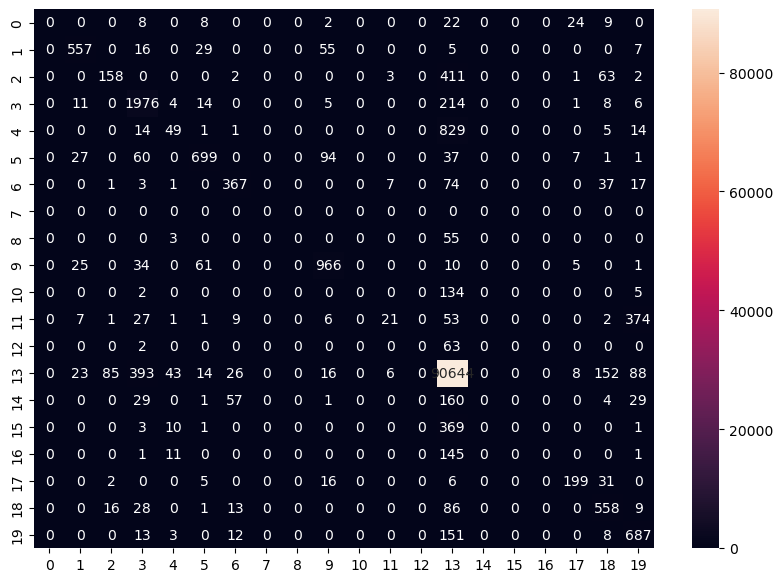

In [19]:
cm=tf.math.confusion_matrix(y_test_flat, predicted_labels_flat)
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True,fmt='d')
plt.xlabel=('Predicted')
plt.ylabel=('Truth')